In [ ]:
# Analyze  daily water intake and hydration levels of individuals based on a combination of demographic, lifestyle, and environmental factors. 
# What we are going to use/do with the dataset is:
    # Hydration level prediction
    # Lifestyle and wellness analysis
    # Feature importance and correlation studies
    # Binary classification models (Good vs Poor hydration)

In [2]:
# Import Libraries
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [3]:
# Load dataset
df = pd.read_csv("Daily_Water_Intake.csv")

In [4]:
# View first 5 rows of dataset
df.head()

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
4,38,Male,77,2.11,Low,Normal,Poor


In [ ]:
# Check structure of dataset
df.info()

# 7 variables: 3 numeric and 4 character
# Character type variables will be recoded later for model

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          30000 non-null  int64  
 1   Gender                       30000 non-null  object 
 2   Weight (kg)                  30000 non-null  int64  
 3   Daily Water Intake (liters)  30000 non-null  float64
 4   Physical Activity Level      30000 non-null  object 
 5   Weather                      30000 non-null  object 
 6   Hydration Level              30000 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.6+ MB


In [ ]:
# view Unique values for each character type variable
for col in df:
    if col == 'Age' or col == 'Daily Water Intake (liters)' or col == 'Weight (kg)':
        continue
    else:
        print(df[col].unique())

# Gender has 2 unique values
# Physical Activity Level has 3 unique values
# Weather has 3 unique values 
# Hydration Level has 2 unique values

['Male' 'Female']
['Moderate' 'High' 'Low']
['Hot' 'Normal' 'Cold']
['Good' 'Poor']


In [ ]:
# check for any missing values in data
df.isnull().sum().sort_values(ascending=False)

# There are no missing values in data

Age                            0
Gender                         0
Weight (kg)                    0
Daily Water Intake (liters)    0
Physical Activity Level        0
Weather                        0
Hydration Level                0
dtype: int64

In [14]:
# Drop any duplicates that exist
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

# Dataset had originally 30,000 observations but now there is 29,662 observations
# There were 338 duplicates in the data

(29662, 7)

In [ ]:
# View summary statistics of numerical values
df.describe()

,Age,Weight (kg),Daily Water Intake (liters)
count,29662.000000,29662.000000,29662.000000
mean,43.408199,77.065471,2.864480
std,14.990058,18.677993,0.829543
min,18.000000,45.000000,1.500000
25%,30.000000,61.000000,2.230000
50%,43.000000,77.000000,2.840000
75%,56.000000,93.000000,3.450000
max,69.000000,109.000000,5.430000


In [19]:
# Look at the count for categorical variables
df.describe(include=['object'])

,Gender,Physical Activity Level,Weather,Hydration Level
count,29662,29662,29662,29662
unique,2,3,3,2
top,Male,High,Hot,Good
freq,14857,10046,10053,23730


In [21]:
# Univariate Analysis
# Select numerical columns and categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

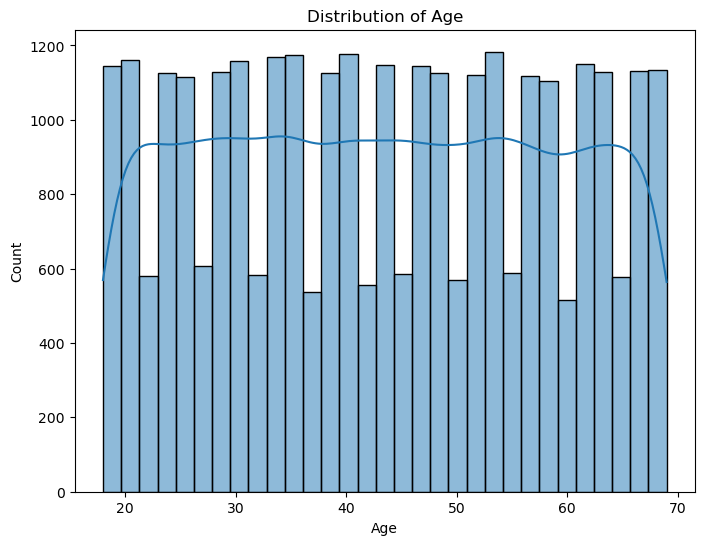

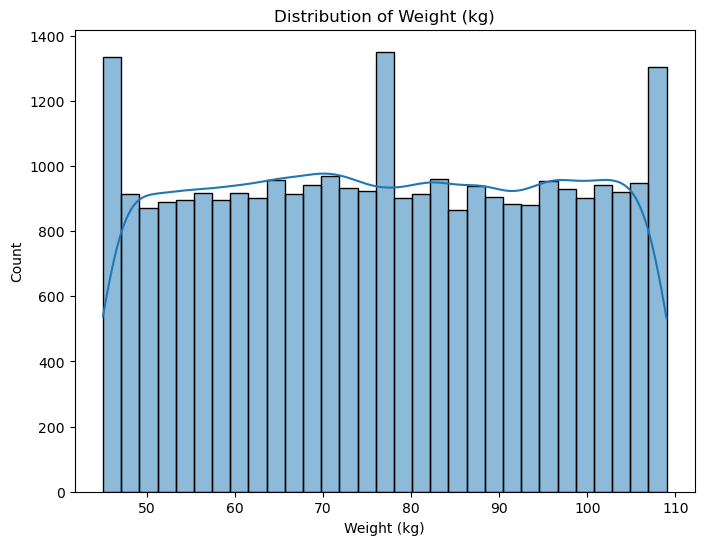

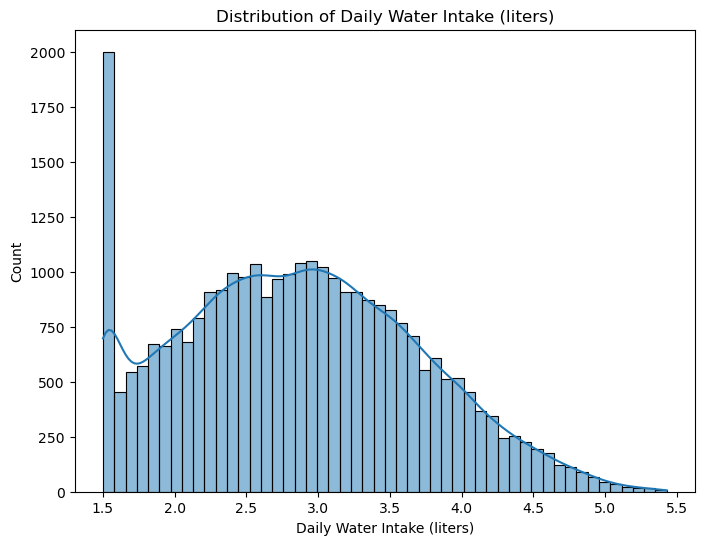

In [22]:
# View histograms of numerical variables
for col in num_cols:
    plt.figure(figsize=(8,6))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

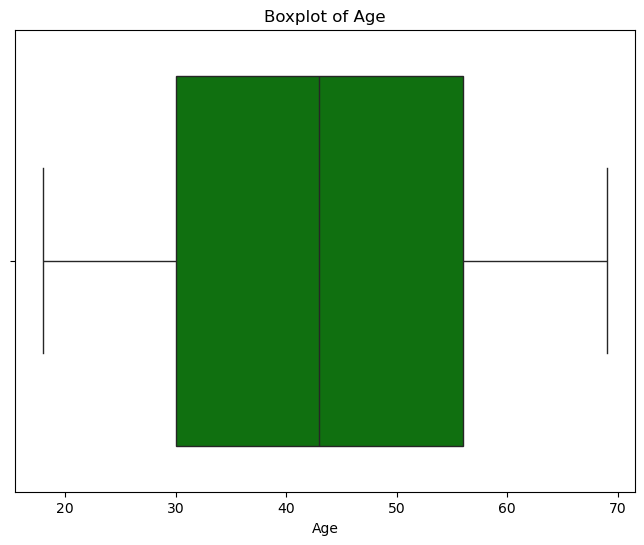

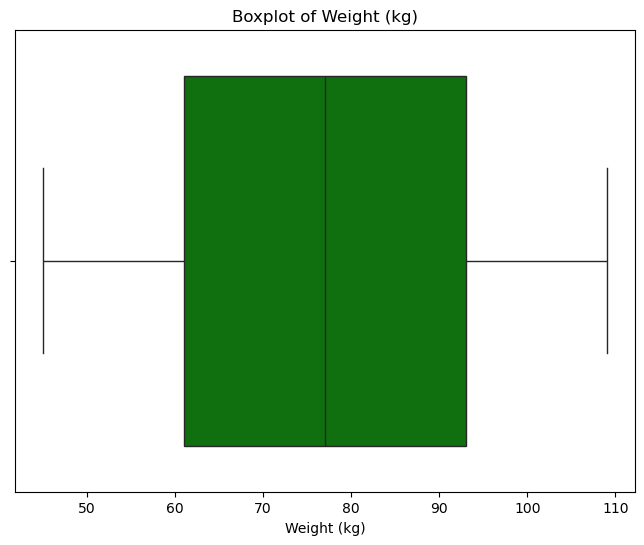

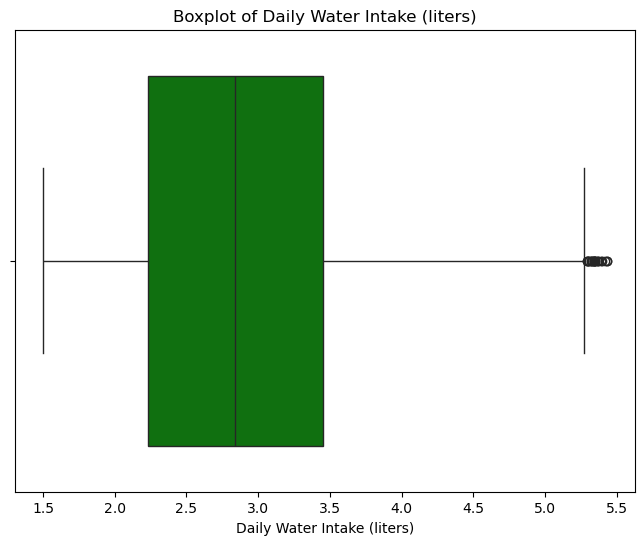

In [ ]:
# Look to see if there are any outliers for numerical variables
for col in num_cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col], color='green')
    plt.title(f"Boxplot of {col}")
    plt.show()

# There are outliers for Daily Water Intake possibly indicating that these individuals could be involved in a physically demanding
# activity or it could be possible outliers

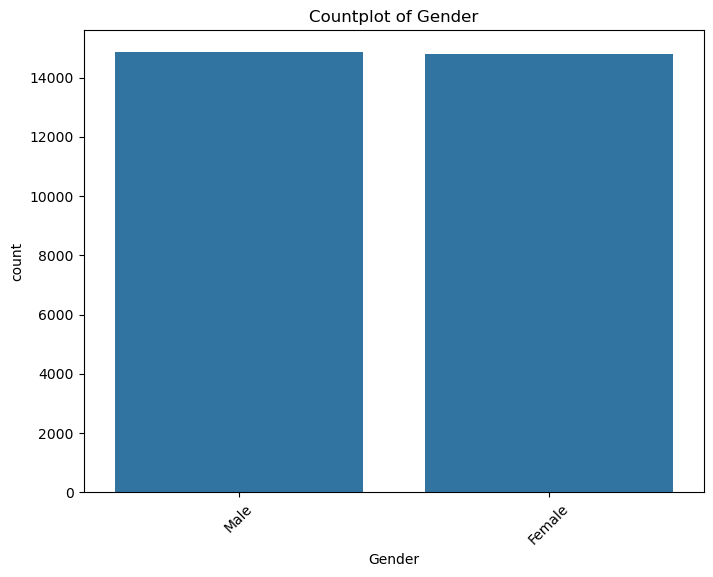

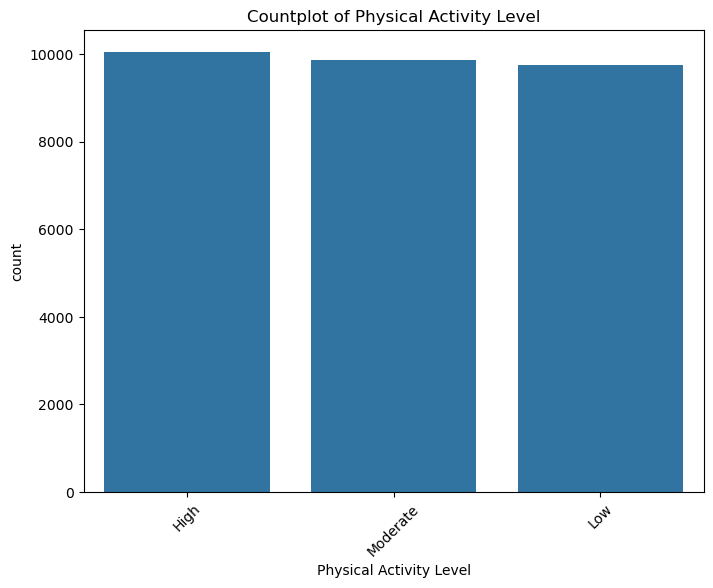

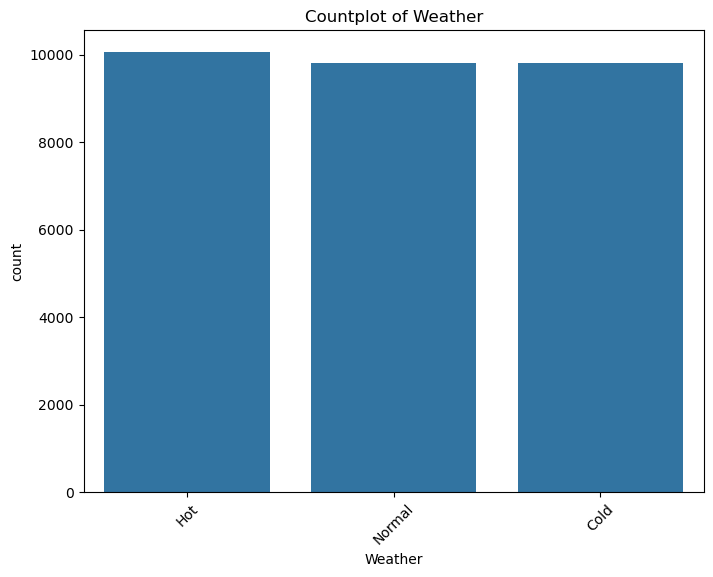

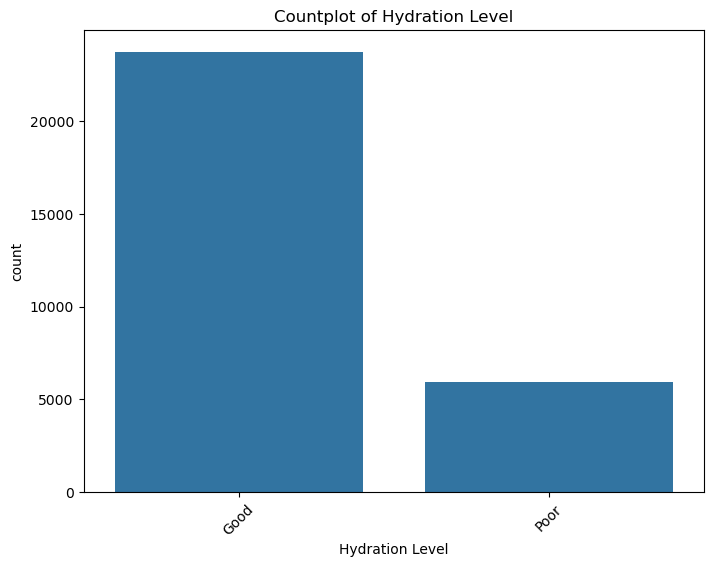

In [24]:
# View countplot of categorical variables
for col in cat_cols:
    plt.figure(figsize=(8,6))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# Even amount of females and males
# Even amount of high, moderate and low physical activity levels
# Even amount of hot, normal and col weather
# Majority of individuals have good hydration level


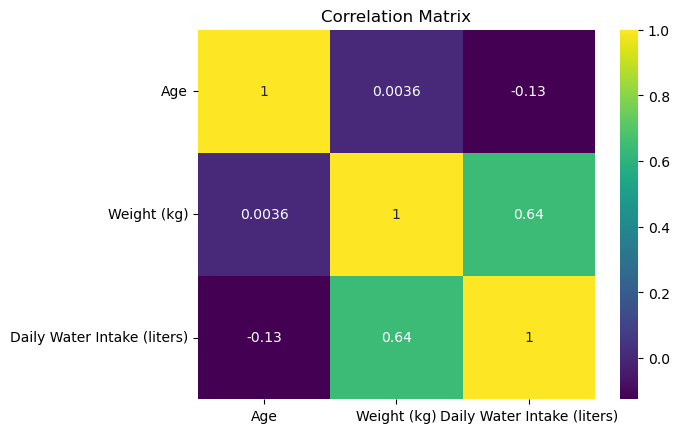

In [ ]:
# Bivariate Analysis

# Look at the correlation among numeric variables
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='viridis')
plt.title('Correlation Matrix')
plt.show()

# Weight and Daiy Water Intake have a strong postive correlation of 0.64
# indicating as Daily Water Intake increases so does weight

In [28]:
# Let's look at how Age, Daily Water Intake and Weight looks across each Gender by looking at the average of each

gender_summary = df.groupby("Gender").agg({
    "Age": "mean",
    "Daily Water Intake (liters)": "mean",
    "Weight (kg)": "mean"
})

In [ ]:
print(gender_summary)

# The average ages for both male and females are roughly the same, water intke is roughly the same and Females weight slightly more than Males.


              Age  Daily Water Intake (liters)  Weight (kg)
Gender                                                     
Female  43.453563                     2.868729    77.235258
Male    43.362994                     2.860246    76.896278


In [30]:
# Let's look at the average age, water intake and weight for each activity level
activity_age = df.groupby("Physical Activity Level")['Age'].mean()
activity_intake = df.groupby("Physical Activity Level")["Daily Water Intake (liters)"].mean()
activity_weight = df.groupby("Physical Activity Level")["Weight (kg)"].mean()

In [31]:
# Put results into dictionary
activity_dict = {
    "Average Age by Activity Level": activity_age,
    "Average Daily Water Intake by Activity Level": activity_intake,
    "Average Weight by Activity Level": activity_weight
}

C:\Users\shirl\AppData\Local\Temp\ipykernel_11148\711011703.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette="viridis")


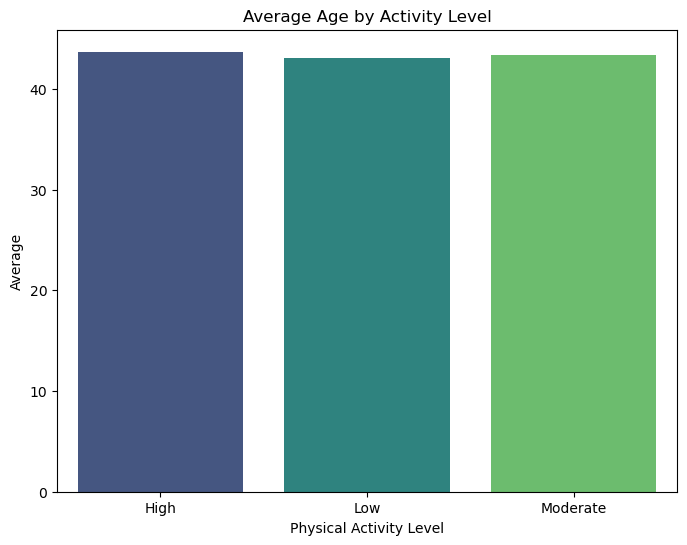

C:\Users\shirl\AppData\Local\Temp\ipykernel_11148\711011703.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette="viridis")


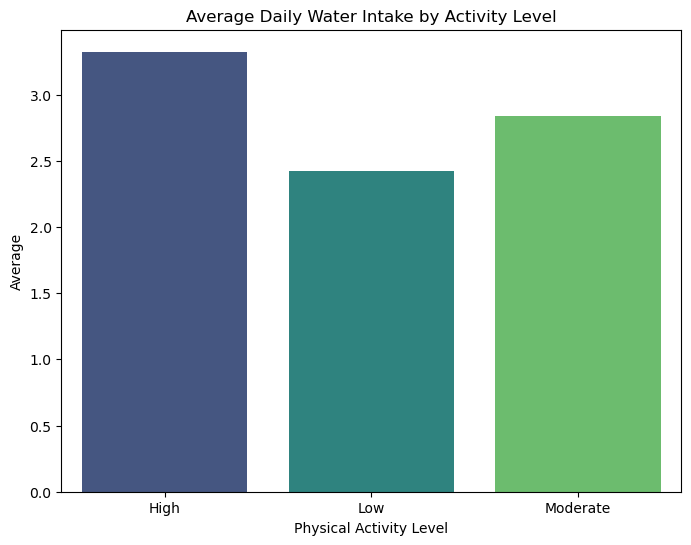

C:\Users\shirl\AppData\Local\Temp\ipykernel_11148\711011703.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette="viridis")


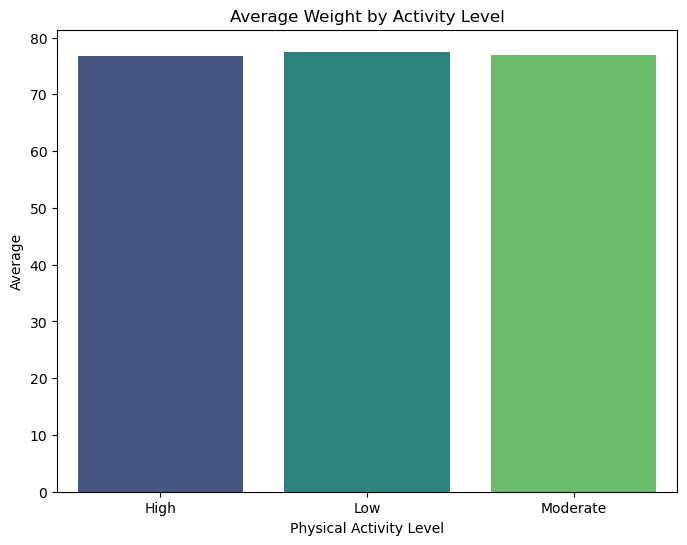

In [33]:
# Loop through dict and plot each
for title, data in activity_dict.items():
    plt.figure(figsize=(8,6))
    sns.barplot(x=data.index, y=data.values, palette="viridis")
    plt.title(title)
    plt.ylabel("Average")
    plt.xlabel("Physical Activity Level")
    plt.show()

In [34]:
df.info(0)

<class 'pandas.core.frame.DataFrame'>
Index: 29662 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          29662 non-null  int64  
 1   Gender                       29662 non-null  object 
 2   Weight (kg)                  29662 non-null  int64  
 3   Daily Water Intake (liters)  29662 non-null  float64
 4   Physical Activity Level      29662 non-null  object 
 5   Weather                      29662 non-null  object 
 6   Hydration Level              29662 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.8+ MB


In [35]:
# Lastly let's look at Hydration Level and how age, weight and daily water intake compares for each group (good or poor)
hydration_summary = df.groupby("Hydration Level").agg({
    "Age": "mean",
    "Weight (kg)": "mean",
    "Daily Water Intake (liters)": "mean"
})

In [ ]:
# print results
print(hydration_summary)

# Average age for poor hydration is higher than average age for good hydration
# Average weight for poor hydration is higher than average weight for good hydration
# Average water intake for good hydration is higher than average water intake for poor hydration

# Meaning: Individuals with good hydration level tends to be younger, weigh less and consume more water daily than there 
# counterparts who have poor hydration

                       Age  Weight (kg)  Daily Water Intake (liters)
Hydration Level                                                     
Good             42.481374    76.233375                     3.053604
Poor             47.115813    80.394134                     2.107921


In [37]:
# Let's encode our categorical variables 
from sklearn.preprocessing import LabelEncoder

In [38]:
# Make copy of original dataframe to use for modeling
model_df = df.copy()

In [39]:
label_enc = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    label_enc[col] = le

In [43]:
for col, le in label_enc.items():
    print(f"\n--- {col} Mapping ---")
    mapping = dict(zip(le.classes_, range(len(le.classes_))))
    for category, integer in mapping.items():
        print(f"{category} -> {integer}")



--- Gender Mapping ---
Female -> 0
Male -> 1

--- Physical Activity Level Mapping ---
High -> 0
Low -> 1
Moderate -> 2

--- Weather Mapping ---
Cold -> 0
Hot -> 1
Normal -> 2

--- Hydration Level Mapping ---
Good -> 0
Poor -> 1


In [45]:
model_df.head()

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,1,96,4.23,2,1,0
1,60,1,105,3.95,0,2,0
2,36,1,68,2.39,2,0,0
3,19,0,74,3.13,2,1,0
4,38,1,77,2.11,1,2,1


In [46]:
# Select predictors and target variable
np.random.seed(42)
X = model_df.drop("Hydration Level", axis=1)
y = model_df["Hydration Level"]

In [48]:
# Train and Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [50]:
# Fit Decision Tree
model_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
model_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [51]:
# Make predictions
y_pred = model_tree.predict(X_test)

In [ ]:
# Let's evaluate model
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# The model is 95% accurate at classifing whether a individual has good or poor hydration level


Accuracy: 0.95

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97      4746
           1       0.85      0.89      0.87      1187

    accuracy                           0.95      5933
   macro avg       0.91      0.93      0.92      5933
weighted avg       0.95      0.95      0.95      5933



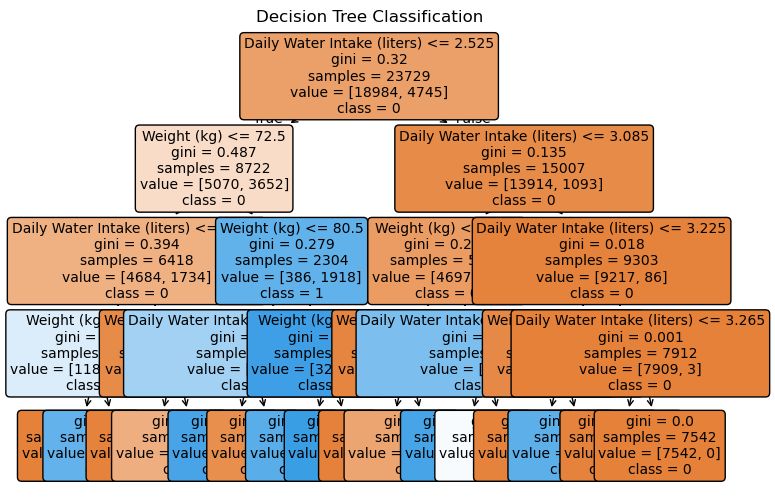

In [53]:
# Visualize Tree
plt.figure(figsize=(8,6))
plot_tree(model_tree, feature_names=X.columns,
          class_names=[str(c) for c in np.unique(y)],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Classification")
plt.show()

In [ ]:
# Feature Importance
feat_import = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_tree.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n", feat_import)

# Weight and Daily Water Intake are the most important features for classifying hydration level
# other predictors can be remove since they have no signifcance/impact on hydration level.


Feature Importance:
                        Feature  Importance
2                  Weight (kg)    0.546202
3  Daily Water Intake (liters)    0.453798
0                          Age    0.000000
1                       Gender    0.000000
4      Physical Activity Level    0.000000
5                      Weather    0.000000
